# Cached Detections

**Note**:
- the cache's `frame_indices` are native-fps `cv2.VideoCapture` read
order, not the same as the sparse annotated `frame_number`s used in
`01_explore_ground_truth.ipynb` — so this notebook reads frames straight from
the clip's video file rather than through `Clip`/`Frame`.

In [2]:
# --- imports
from pathlib import Path
import random

import cv2
import numpy as np
import supervision as sv

from orc_model.data import ClipDataset

# --- config
CLIP_NAME = "IMG_2081"
DATA_DIR = Path("../data")
N_FRAMES_TO_SHOW = 5

## Load detections

In [ ]:
# --- load the raw cache and sanity-check it
cache = np.load(DATA_DIR / CLIP_NAME / "detections_cache.npz")
print(cache.files)

['frame_indices', 'xyxy', 'confidence', 'class_id', 'mask_bits', 'mask_bit_counts', 'image_height', 'image_width']


## Decode into `sv.Detections` per frame

Masks are stored bit-packed and cropped to each detection's own box (to keep
the file small), so decoding means unpacking bits and pasting them back into
a full-frame canvas at the box's location.

In [6]:
def load_cached_detections(cache: np.lib.npyio.NpzFile) -> dict[int, sv.Detections]:
    """Frame indices absent from the returned dict had zero detections —
    treat a missing key as `sv.Detections.empty()`."""
    
    frame_indices = cache["frame_indices"]
    xyxy = cache["xyxy"]
    confidence = cache["confidence"]
    class_id = cache["class_id"]
    mask_bits = cache["mask_bits"]
    mask_bit_counts = cache["mask_bit_counts"]
    image_height, image_width = int(cache["image_height"]), int(cache["image_width"])

    byte_counts = np.ceil(mask_bit_counts / 8).astype(np.int64)
    byte_offsets = np.concatenate([[0], np.cumsum(byte_counts)])

    detections_by_frame = {}
    for frame_index in np.unique(frame_indices):
        det_indices = np.where(frame_indices == frame_index)[0]
        masks = np.zeros((len(det_indices), image_height, image_width), dtype=bool)
        for out_i, det_i in enumerate(det_indices):
            x1, y1, x2, y2 = xyxy[det_i]
            x1 = min(max(int(np.floor(x1)), 0), image_width)
            y1 = min(max(int(np.floor(y1)), 0), image_height)
            x2 = min(max(int(np.ceil(x2)), x1), image_width)
            y2 = min(max(int(np.ceil(y2)), y1), image_height)
            n_bits = int(mask_bit_counts[det_i])
            packed = mask_bits[byte_offsets[det_i] : byte_offsets[det_i + 1]]
            cropped = np.unpackbits(packed, count=n_bits).astype(bool).reshape(y2 - y1, x2 - x1)
            masks[out_i, y1:y2, x1:x2] = cropped

        detections_by_frame[int(frame_index)] = sv.Detections(
            xyxy=xyxy[det_indices],
            mask=masks,
            confidence=confidence[det_indices],
            class_id=class_id[det_indices],
        )
    return detections_by_frame

In [7]:
# get the detections
detections_by_frame = load_cached_detections(cache)
print(f"{len(detections_by_frame)} frames with at least one cached detection")

# --- the video itself lives next to the cache (same clip layout as ClipDataset)
clip = ClipDataset.from_data_dir(DATA_DIR).get_clip(CLIP_NAME)
print(clip.video_path, clip.fps, clip.resolution)

1742 frames with at least one cached detection
../data/IMG_2081/video/IMG_2081.mp4 30.0 (1920, 1080)


## `PredictedClip`

In [11]:
import io
from PIL import Image

class PredictedFrame:
    """Read-only view of one cached-prediction frame — mirrors `Frame`'s
    display/detections interface (`.to_detections()`, `.image`, auto-render),
    backed by the decoded cache + a video seek instead of COCO annotations +
    a pre-extracted still."""

    def __init__(self, frame_index: int, detections: sv.Detections, clip: "PredictedClip") -> None:
        self.frame_index = frame_index
        self.detections = detections
        self._clip = clip

    def load_image(self) -> np.ndarray:
        return self._clip._read_frame(self.frame_index)

    @property
    def image(self) -> Image.Image:
        return Image.fromarray(cv2.cvtColor(self.load_image(), cv2.COLOR_BGR2RGB))

    def _repr_png_(self) -> bytes:
        buffer = io.BytesIO()
        self.image.save(buffer, format="PNG")
        return buffer.getvalue()

    def to_detections(self) -> sv.Detections:
        return self.detections


class PredictedClip:
    """Same shape as `Clip` (indexable, `.to_detections()` per frame), backed
    by a cached-detections `.npz` + video seek instead of COCO annotations +
    extracted stills.

    Indexed by the cache's own `frame_index` (native video decode position),
    NOT by list position like `Clip` — those aren't the same set of frames
    (the cache covers ~every decoded frame; `Clip` only the sparse
    hand-annotated subset), so keeping the indexing distinct is the point,
    not an oversight.
    """

    def __init__(self, name: str, video_path: Path, detections_by_frame: dict[int, sv.Detections]) -> None:
        self.name = name
        self.video_path = video_path
        self.detections_by_frame = detections_by_frame
        self.frame_indices = sorted(detections_by_frame)
        self._capture: cv2.VideoCapture | None = None

    @classmethod
    def from_cache(cls, clip_name: str, data_dir: Path) -> "PredictedClip":
        cache = np.load(data_dir / clip_name / "detections_cache.npz")
        detections_by_frame = load_cached_detections(cache)
        video_path = ClipDataset.from_data_dir(data_dir).get_clip(clip_name).video_path
        return cls(name=clip_name, video_path=video_path, detections_by_frame=detections_by_frame)

    def _read_frame(self, frame_index: int) -> np.ndarray:
        if self._capture is None:
            self._capture = cv2.VideoCapture(str(self.video_path))
        self._capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ok, frame = self._capture.read()
        assert ok, f"couldn't read frame {frame_index} from {self.video_path}"
        return frame

    def __len__(self) -> int:
        return len(self.frame_indices)

    def __iter__(self):
        return (self[i] for i in self.frame_indices)

    def __getitem__(self, frame_index: int) -> PredictedFrame:
        if frame_index not in self.detections_by_frame:
            raise KeyError(
                f"No cached detections for frame {frame_index} in {self.name!r} "
                "(indexed by native video frame position — see `.frame_indices` "
                "for which frames have cached detections)."
            )
        return PredictedFrame(frame_index, self.detections_by_frame[frame_index], self)

predicted_clip = PredictedClip.from_cache(CLIP_NAME, DATA_DIR)
print(f"{predicted_clip.name}: {len(predicted_clip)} frames with cached detections")

IMG_2081: 1742 frames with cached detections


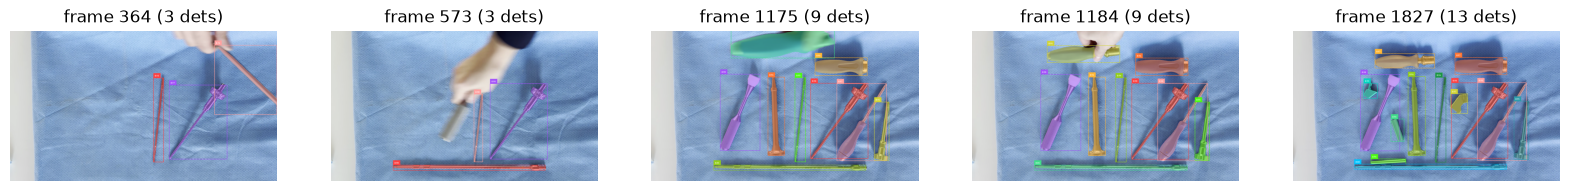

In [13]:
# --- pick a few cached frames at random and overlay their predictions
mask_annotator = sv.MaskAnnotator(opacity=0.5, color_lookup=sv.ColorLookup.INDEX)
box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

selected = sorted(random.sample(predicted_clip.frame_indices, k=min(N_FRAMES_TO_SHOW, len(predicted_clip))))

grid_images = []
grid_titles = []
for frame_index in selected:
    frame = predicted_clip[frame_index]
    image = frame.load_image()
    detections = frame.to_detections()
    labels = [f"{conf:.2f}" for conf in detections.confidence]

    annotated = mask_annotator.annotate(image.copy(), detections)
    annotated = box_annotator.annotate(annotated, detections)
    annotated = label_annotator.annotate(annotated, detections, labels=labels)

    grid_images.append(annotated)
    grid_titles.append(f"frame {frame_index} ({len(detections)} dets)")

sv.plot_images_grid(grid_images, grid_size=(1, len(grid_images)), titles=grid_titles, size=(20, 6))